In [ ]:
%pip uninstall -y torchtext torch
%pip install torch==2.3.0+cpu torchvision==0.18.0+cpu torchaudio==2.3.0+cpu -f https://download.pytorch.org/whl/torch_stable.html
%pip install torchtext==0.18.0 --no-deps

Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Looking in links: https://download.pytorch.org/whl/torch_stable.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 MB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.9 MB/s eta 0:00:00
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.25.0+cpu
    Uninstalling torchvision-0.25.0+cpu:
      Successfully uninstalled torchvision-0.25.0+cpu
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.10.0+cpu
    Uninstalling torchaudio-2.10.0+cpu:
      Successfully uninstalled torchaudio-2.10.0+cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.4 MB/s eta 0:00:00


In [ ]:
import datasets
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
from torchtext.vocab import build_vocab_from_iterator
from torch.nn.utils.rnn import pad_sequence
import pandas as pd

/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [ ]:
import os
os.environ["HF_TOKEN"] = ""

In [ ]:
data = datasets.load_dataset("facebook/bouquet", "fra_Latn", split="dev")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/108 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/108 [00:00<?, ?it/s]

data/sentence_level/dev/fra_Latn.parquet:   0%|          | 0.00/120k [00:00<?, ?B/s]

data/sentence_level/test/fra_Latn.parque(…):   0%|          | 0.00/186k [00:00<?, ?B/s]

Generating dev split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
def is_french(dataset):
    return dataset['src_lang'] == 'fra_Latn'

In [ ]:
data = data.filter(is_french)

source_sentences = data['src_text']
target_sentences = data['tgt_text']

Filter:   0%|          | 0/504 [00:00<?, ? examples/s]

In [ ]:
def tokenize(sentences):
    return [s.lower().split() for s in sentences]


tokenized_source = tokenize(source_sentences)
tokenized_target = tokenize(target_sentences)

In [ ]:
source_vocab = build_vocab_from_iterator(tokenized_source, specials=["<pad>", "<sos>", "<eos>"])
target_vocab = build_vocab_from_iterator(tokenized_target, specials=["<pad>", "<sos>", "<eos>"])

source_vocab.set_default_index(source_vocab["<pad>"])
target_vocab.set_default_index(target_vocab["<pad>"])


In [ ]:
def encode(sentences, vocab):
    return [[vocab["<sos>"]] + vocab(s) + [vocab["<eos>"]] for s in sentences]

encoded_source = encode(tokenized_source, source_vocab)
encoded_target = encode(tokenized_target, target_vocab)

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, src, tgt):
        self.src = src
        self.tgt = tgt
    def __len__(self):
        return len(self.src)
    def __getitem__(self, idx):
        return torch.tensor(self.src[idx]), torch.tensor(self.tgt[idx])

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, n_layers=1, bidirectional=False, model_type='lstm'):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim)
        self.n_layers = n_layers
        self.bidirectional = bidirectional
        if model_type == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers, bidirectional=bidirectional)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, bidirectional=bidirectional)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)

        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, n_layers=1, model_type='lstm'):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim)
        self.n_layers = n_layers
        if model_type == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden):
        input = input.unsqueeze(0)

        embedded = self.embedding(input)

        output, hidden = self.rnn(embedded, hidden)

        prediction = self.fc_out(output.squeeze(0))

        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device, model_type='lstm'):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.model_type = model_type

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):

        batch_size = tgt.shape[1]
        tgt_len = tgt.shape[0]
        tgt_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(tgt_len, batch_size, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src)

        if self.encoder.bidirectional:
            if self.model_type == 'lstm':
                h_n, c_n = hidden

                h_n = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1).unsqueeze(0).repeat(self.decoder.n_layers, 1, 1)
                c_n = torch.cat((c_n[-2, :, :], c_n[-1, :, :]), dim=1).unsqueeze(0).repeat(self.decoder.n_layers, 1, 1)
                hidden = (h_n, c_n)
            else: # GRU
                h_n = hidden
                h_n = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1).unsqueeze(0).repeat(self.decoder.n_layers, 1, 1)
                hidden = h_n
        else:
            if self.model_type == 'lstm':
                h_n, c_n = hidden
                h_n = h_n[-self.decoder.n_layers:, :, :]
                c_n = c_n[-self.decoder.n_layers:, :, :]
                hidden = (h_n, c_n)
            else: # GRU
                h_n = hidden
                h_n = h_n[-self.decoder.n_layers:, :, :]
                hidden = h_n

        input = tgt[0,:]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = tgt[t] if teacher_force else top1

        return outputs

In [ ]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, padding_value=source_vocab["<pad>"])
    tgt_batch = pad_sequence(tgt_batch, padding_value=target_vocab["<pad>"])
    return src_batch, tgt_batch

In [ ]:
train_src, test_src, train_tgt, test_tgt = train_test_split(encoded_source, encoded_target, test_size=0.2, random_state=42)

train_dataset = TranslationDataset(train_src, train_tgt)
test_dataset = TranslationDataset(test_src, test_tgt)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


In [ ]:
import random

def train_model(model, data_loader, n_epochs=50, lr=0.001, device='cpu'):
    criterion = nn.CrossEntropyLoss(ignore_index=target_vocab["<pad>"])
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    history = {'loss': []}

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for src, tgt in data_loader:
            src, tgt = src.to(device), tgt.to(device)

            optimizer.zero_grad()

            output = model(src, tgt)

            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            tgt = tgt[1:].view(-1)

            loss = criterion(output, tgt)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_epoch_loss = epoch_loss / len(data_loader)
        history['loss'].append(avg_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {avg_epoch_loss:.4f}")
    return model, history

In [ ]:
input_dim = len(source_vocab)
output_dim = len(target_vocab)
embed_dim = 256
hidden_dim = 512
n_layers = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

decoder_hidden_dim = hidden_dim * 2

encoder_lstm = Encoder(input_dim, embed_dim, hidden_dim, n_layers=n_layers, bidirectional=True, model_type='lstm')
decoder_lstm = Decoder(output_dim, embed_dim, decoder_hidden_dim, n_layers=n_layers, model_type='lstm')
lstm_model = Seq2Seq(encoder_lstm, decoder_lstm, device, model_type='lstm')

encoder_gru = Encoder(input_dim, embed_dim, hidden_dim, n_layers=n_layers, bidirectional=True, model_type='gru')
decoder_gru = Decoder(output_dim, embed_dim, decoder_hidden_dim, n_layers=n_layers, model_type='gru')
gru_model = Seq2Seq(encoder_gru, decoder_gru, device, model_type='gru')

In [ ]:
print("Training LSTM Model...")
lstm_model, lstm_history = train_model(lstm_model, train_loader, device=device)
print("Training GRU Model...")
gru_model, gru_history = train_model(gru_model, train_loader, device=device)

Training LSTM Model...
Epoch 1, Loss: 7.1376
Epoch 2, Loss: 6.4359
Epoch 3, Loss: 6.2140
Epoch 4, Loss: 6.0502
Epoch 5, Loss: 5.8947
Epoch 6, Loss: 5.7571
Epoch 7, Loss: 5.6278
Epoch 8, Loss: 5.4674
Epoch 9, Loss: 5.3282
Epoch 10, Loss: 5.2149
Epoch 11, Loss: 5.0603
Epoch 12, Loss: 4.8948
Epoch 13, Loss: 4.7587
Epoch 14, Loss: 4.5902
Epoch 15, Loss: 4.4402
Epoch 16, Loss: 4.2266
Epoch 17, Loss: 4.0543
Epoch 18, Loss: 3.8431
Epoch 19, Loss: 3.6058
Epoch 20, Loss: 3.3470
Epoch 21, Loss: 3.1523
Epoch 22, Loss: 2.7382
Epoch 23, Loss: 2.4676
Epoch 24, Loss: 2.1406
Epoch 25, Loss: 1.8214
Epoch 26, Loss: 1.5091
Epoch 27, Loss: 1.1732
Epoch 28, Loss: 0.9582
Epoch 29, Loss: 0.6734
Epoch 30, Loss: 0.4889
Epoch 31, Loss: 0.3239
Epoch 32, Loss: 0.2212
Epoch 33, Loss: 0.1479
Epoch 34, Loss: 0.1098
Epoch 35, Loss: 0.0839
Epoch 36, Loss: 0.0669
Epoch 37, Loss: 0.0572
Epoch 38, Loss: 0.0480
Epoch 39, Loss: 0.0422
Epoch 40, Loss: 0.0388
Epoch 41, Loss: 0.0342
Epoch 42, Loss: 0.0310
Epoch 43, Loss: 0.02

In [ ]:
def predict(model, src_sequence, device='cpu', max_len=50):
    model.eval()
    with torch.no_grad():
        tokens = [source_vocab["<sos>"]] + source_vocab(src_sequence.lower().split()) + [source_vocab["<eos>"]]
        src_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(1).to(device)

        encoder_outputs, hidden = model.encoder(src_tensor)

        if model.encoder.bidirectional:
            if model.model_type == 'lstm':
                h_n, c_n = hidden

                h_n = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1).unsqueeze(0).repeat(model.decoder.n_layers, 1, 1)
                c_n = torch.cat((c_n[-2, :, :], c_n[-1, :, :]), dim=1).unsqueeze(0).repeat(model.decoder.n_layers, 1, 1)
                hidden = (h_n, c_n)
            else:
                h_n = hidden
                h_n = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1).unsqueeze(0).repeat(model.decoder.n_layers, 1, 1)
                hidden = h_n
        else:

            if model.model_type == 'lstm':
                h_n, c_n = hidden
                h_n = h_n[-model.decoder.n_layers:, :, :]
                c_n = c_n[-model.decoder.n_layers:, :, :]
                hidden = (h_n, c_n)
            else:
                h_n = hidden
                h_n = h_n[-model.decoder.n_layers:, :, :]
                hidden = h_n

        input_token = torch.tensor([target_vocab["<sos>"]], dtype=torch.long).to(device)

        translated_tokens = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            top1 = output.argmax(1)
            translated_tokens.append(top1.item())

            if top1.item() == target_vocab["<eos>"]:
                break

            input_token = top1

        predicted_words = [target_vocab.lookup_token(t) for t in translated_tokens if t not in [target_vocab["<sos>"], target_vocab["<eos>"]]]

    return " ".join(predicted_words)

In [ ]:
test_samples = [s for s in data['src_text'][len(train_src):]]
for test in test_samples[:10]:
  print(f'Test samples e.g., {test}')

Test samples e.g., 3) Qui est sorti avec qui après l'école
Test samples e.g., 4) Avec qui Bob en particulier est-il sorti
Test samples e.g., 5) Comment faire rentrer clandestinement un lecteur à l'école
Test samples e.g., La poursuite continua.
Test samples e.g., Il sauta par-dessus la clôture, laissant derrière lui un nuage de poussière.
Test samples e.g., Il y avait une ruelle sombre devant lui, avec des poubelles et il sauta également par-dessus.
Test samples e.g., Il semblait que les poursuivants étaient distancés, mais ce n'était qu'une illusion.
Test samples e.g., Il continua à courir.
Test samples e.g., C'est la journée au spa de Musya.
Test samples e.g., Notre but n'est pas seulement de nettoyer la fourrure, mais aussi de permettre à Musya de se détendre et de se débarrasser de son stress.


In [ ]:
pred_lstm = [predict(lstm_model, s) for s in test_samples]
pred_gru = [predict(gru_model, s) for s in test_samples]

In [ ]:
print("Sample Predictions:")
for i in range(15):
    original_target_sentence = data['tgt_text'][len(train_src) + i]
    print(f"\nSource: {test_samples[i]}")
    print(f"Target (Actual): {original_target_sentence}")
    print(f"Predicted (LSTM): {pred_lstm[i]}")
    print(f"Predicted (GRU): {pred_gru[i]}")

print("\nThis concludes the model training and prediction demonstration.")

Sample Predictions:

Source: 3) Qui est sorti avec qui après l'école
Target (Actual): 3) Who went out with whom after school
Predicted (LSTM): 3) who went out with whom after school
Predicted (GRU): 3) who went out with whom after school

Source: 4) Avec qui Bob en particulier est-il sorti
Target (Actual): 4) Bob in particular, whom he went out with
Predicted (LSTM): 4) bob in particular, whom he went out with
Predicted (GRU): 4) bob in particular, whom he went out with

Source: 5) Comment faire rentrer clandestinement un lecteur à l'école
Target (Actual): 5) How to smuggle a player into school
Predicted (LSTM): 5) how to smuggle a player into school
Predicted (GRU): 5) how to smuggle a player into school

Source: La poursuite continua.
Target (Actual): The chase went on
Predicted (LSTM): the price is the too
Predicted (GRU): the chase went for the sea, the suspects and witnesses.

Source: Il sauta par-dessus la clôture, laissant derrière lui un nuage de poussière.
Target (Actual):  He

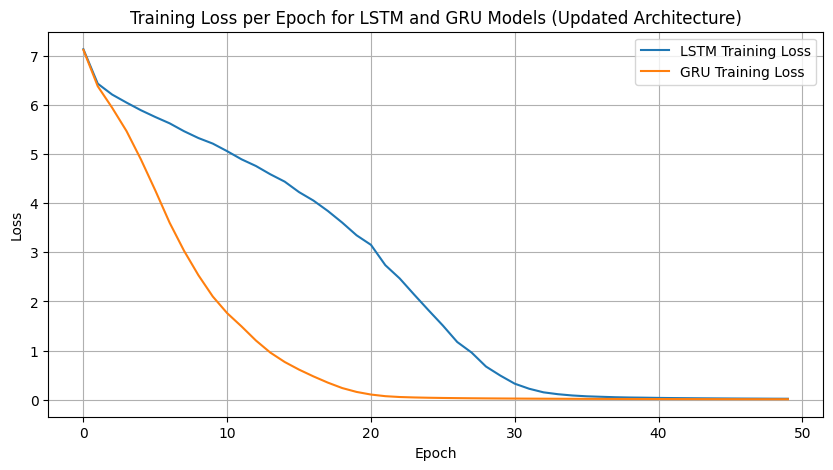

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(lstm_history['loss'], label='LSTM Training Loss')
plt.plot(gru_history['loss'], label='GRU Training Loss')
plt.title('Training Loss per Epoch for LSTM and GRU Models (Updated Architecture)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from torchtext.data.metrics import bleu_score

def calculate_bleu(model, data_loader, target_vocab, device='cpu'):
    trg_sentences = []
    pred_sentences = []

    model.eval()
    with torch.no_grad():
        for src, tgt in data_loader:
            src = src.to(device)

            for i in range(src.shape[1]):
                single_src = src[:, i].unsqueeze(1)
                encoder_outputs, hidden = model.encoder(single_src)

                if model.encoder.bidirectional:
                    if model.model_type == 'lstm':
                        h_n, c_n = hidden
                        h_n = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1).unsqueeze(0).repeat(model.decoder.n_layers, 1, 1)
                        c_n = torch.cat((c_n[-2, :, :], c_n[-1, :, :]), dim=1).unsqueeze(0).repeat(model.decoder.n_layers, 1, 1)
                        hidden = (h_n, c_n)
                    else: # GRU
                        h_n = hidden
                        h_n = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1).unsqueeze(0).repeat(model.decoder.n_layers, 1, 1)
                        hidden = h_n
                else:
                    if model.model_type == 'lstm':
                        h_n, c_n = hidden
                        h_n = h_n[-model.decoder.n_layers:, :, :]
                        c_n = c_n[-model.decoder.n_layers:, :, :]
                        hidden = (h_n, c_n)
                    else: # GRU
                        h_n = hidden
                        h_n = h_n[-model.decoder.n_layers:, :, :]
                        hidden = h_n

                input_token = torch.tensor([target_vocab["<sos>"]], dtype=torch.long).to(device)

                translated_tokens = []

                for _ in range(50):
                    output, hidden = model.decoder(input_token, hidden)
                    top1 = output.argmax(1)
                    translated_tokens.append(top1.item())

                    if top1.item() == target_vocab["<eos>"]:
                        break

                    input_token = top1

                predicted_words = [target_vocab.lookup_token(t) for t in translated_tokens if t not in [target_vocab["<sos>"], target_vocab["<eos>"]]]
                pred_sentences.append(predicted_words)

                actual_words = [target_vocab.lookup_token(t.item()) for t in tgt[:, i] if t.item() not in [target_vocab["<sos>"], target_vocab["<eos>"], target_vocab["<pad>"]]]
                trg_sentences.append([actual_words])

    return bleu_score(pred_sentences, trg_sentences)

print("Calculating BLEU scores...")
lstm_bleu = calculate_bleu(lstm_model, test_loader, target_vocab, device)
gru_bleu = calculate_bleu(gru_model, test_loader, target_vocab, device)

print(f"LSTM Model BLEU Score: {lstm_bleu*100:.2f}")
print(f"GRU Model BLEU Score: {gru_bleu*100:.2f}")

/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


Calculating BLEU scores...
LSTM Model BLEU Score: 0.87
GRU Model BLEU Score: 0.98


In [ ]:
print("Sample Predictions:")
for i in range(5):
    original_target_sentence = data['tgt_text'][len(train_src) + i]
    print(f"\nSource: {test_samples[i]}")
    print(f"Target (Actual): {original_target_sentence}")
    print(f"Predicted (LSTM): {pred_lstm[i]}")
    print(f"Predicted (GRU): {pred_gru[i]}")

print("\nThis concludes the model training and prediction demonstration.")

Sample Predictions:

Source: 3) Qui est sorti avec qui après l'école
Target (Actual): 3) Who went out with whom after school
Predicted (LSTM): 3) who went out with whom after school
Predicted (GRU): 3) who went out with whom after school

Source: 4) Avec qui Bob en particulier est-il sorti
Target (Actual): 4) Bob in particular, whom he went out with
Predicted (LSTM): 4) bob in particular, whom he went out with
Predicted (GRU): 4) bob in particular, whom he went out with

Source: 5) Comment faire rentrer clandestinement un lecteur à l'école
Target (Actual): 5) How to smuggle a player into school
Predicted (LSTM): 5) how to smuggle a player into school
Predicted (GRU): 5) how to smuggle a player into school

Source: La poursuite continua.
Target (Actual): The chase went on
Predicted (LSTM): the price is the too
Predicted (GRU): the chase went for the sea, the suspects and witnesses.

Source: Il sauta par-dessus la clôture, laissant derrière lui un nuage de poussière.
Target (Actual):  He

In [ ]:
pred_lstm = [predict(lstm_model, s) for s in test_samples]
pred_gru = [predict(gru_model, s) for s in test_samples]

Really bad scores